In [ ]:
import torch
from torch import nn

class RoPEAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None  # 缓存最近一次的注意力权重用于可视化

    def _rotate_half(self, x):
        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)
    
    def _rope(self, q, k, base=10000):
        seq_len = q.size(1)
        freqs = torch.arange(0, self.d_model, 2, device=q.device) / self.d_model
        freqs = base ** freqs  # (d_model/2,)
        positions = torch.arange(seq_len, device=q.device)  # (seq_len,)
        angles = positions[:, None] / freqs[None, :]  # (seq_len, d_model/2)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        q_rot = self._rotate_half(q)
        k_rot = self._rotate_half(k)
        q = q * cos + q_rot * sin
        k = k * cos + k_rot * sin
        return q, k
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x)
        K = self.w_k(x)
        V = self.w_v(x)
        Q, K = self._rope(Q, K)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_model ** 0.5 # @等价于torch.matmul函数 为方便使用@
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()  # 缓存
        output = attn_w @ V          # (batch, seq_len, d_model)
        return self.out(output)      # (batch, seq_len, output_dim)


In [9]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y

epochs = 1000

model = RoPEAttention(vocab_size=11, output_dim=10, d_model=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_seq_batch(1024, 10, 10)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 1.3906
Epoch 200, Loss: 0.0403
Epoch 300, Loss: 0.0026
Epoch 400, Loss: 0.0011
Epoch 500, Loss: 0.0006
Epoch 600, Loss: 0.0004
Epoch 700, Loss: 0.0003
Epoch 800, Loss: 0.0002
Epoch 900, Loss: 0.0002
Epoch 1000, Loss: 0.0001


In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens=None, title="Attention Weights", cmap="Blues"):
    # attn_w: (batch, T, T) 或 (T, T)
    if attn_w.dim() == 2:
        attn_w = attn_w.unsqueeze(0)
    attn_w = attn_w[:4].detach().cpu().float()   # 取前4个样本

    seq_len = attn_w.shape[1]
    if tokens is None:
        tokens = [str(i) for i in range(seq_len)]

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks(range(seq_len)); ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(range(seq_len)); ax.set_yticklabels(tokens, fontsize=7)
        ax.set_title(f"{title} [{n}]", fontsize=9)
        for i in range(seq_len):
            for j in range(seq_len):
                val = attn_w[n, i, j].item()
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if val > 0.6 else "black")

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

real: tensor([5, 7, 6, 1])
pred: tensor([5, 7, 6, 1])


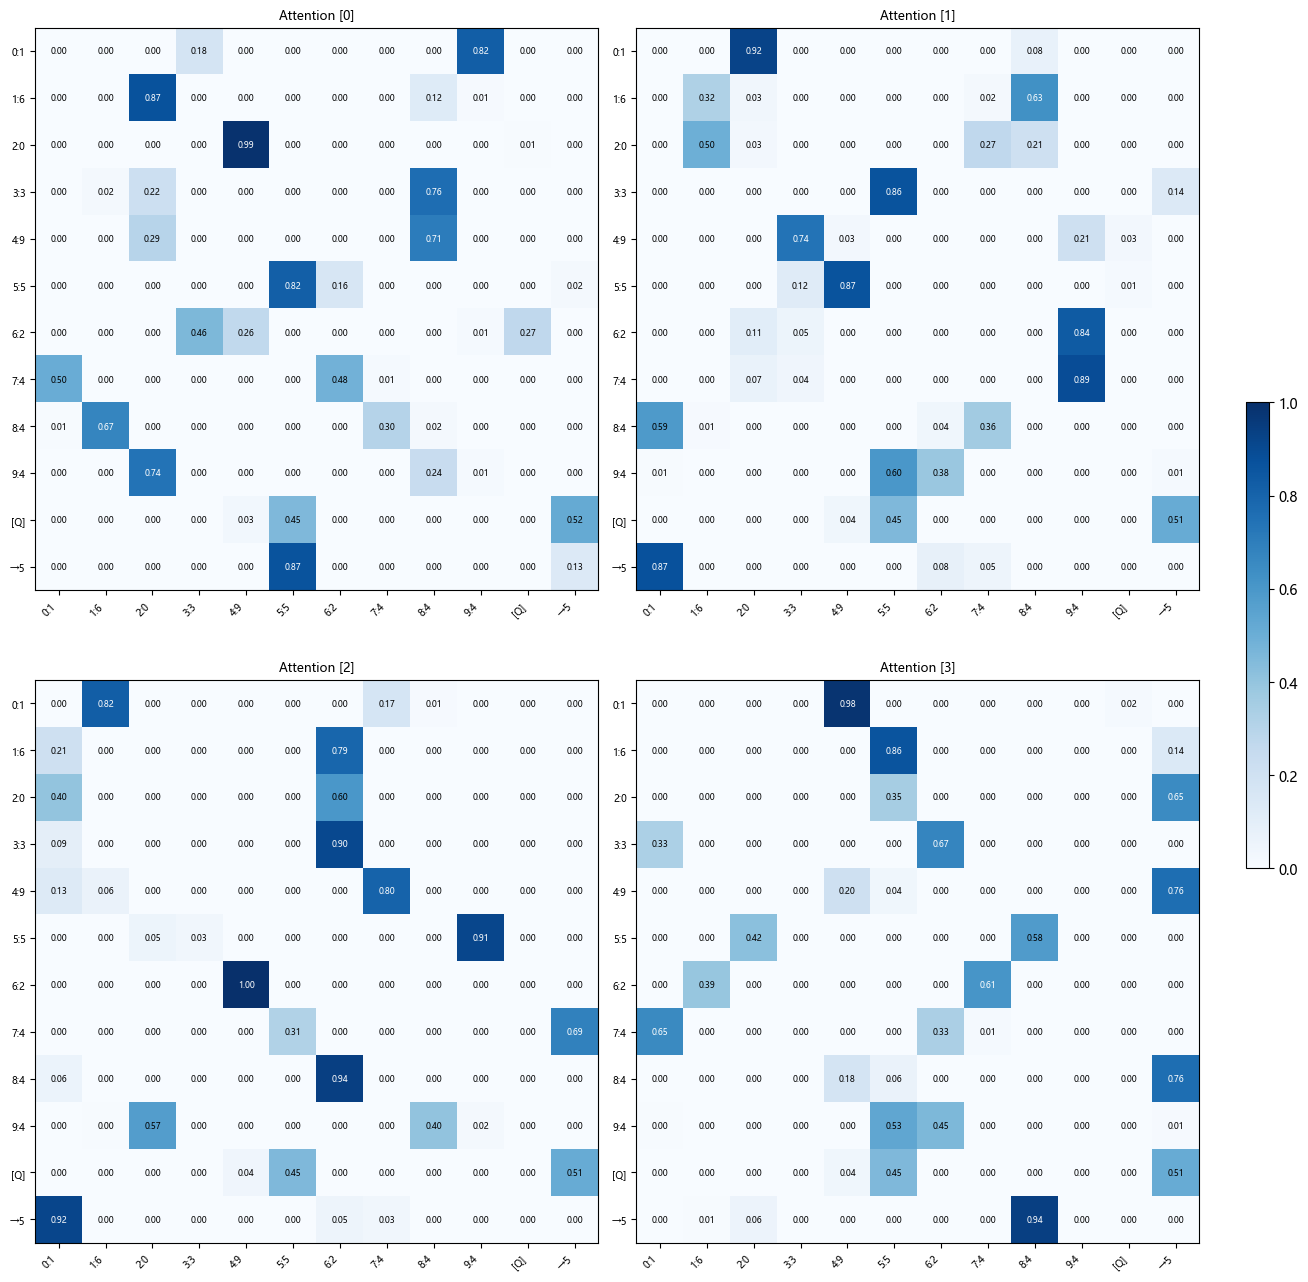

In [12]:
model.eval()
test_x, test_y = get_seq_batch(4, 10, 10)
values = test_x[0, :10].tolist()
q_idx  = test_x[0, -1].item()
query_labels = [f"{i}:{v}" for i, v in enumerate(values)] + ["[Q]", f"→{q_idx}"]
with torch.no_grad():
    pred = model(test_x)[:, -1, :]
    print("real:", test_y)
    print("pred:", pred.argmax(dim=-1))
    plot_attention(model.attn_w, tokens=query_labels, title="Attention")